# Scrap and quality

Where is recorded scrap concentrated?

**Synthetic steel fabrication portfolio. No confidential company data or real-plant improvement claims.**

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Start from the repository or notebooks folder'
sys.path.insert(0, str(ROOT / 'src'))
from cleaning import clean_data
from kpi import summarize, grouped, pareto, operation_capacity
raw = pd.read_csv(ROOT / 'data/raw/manufacturing_data.csv')
clean = clean_data(raw)


,defect_type,scrap_quantity,share,cumulative_share
0,Welding defect,16698,0.272247,0.272247
1,Other,12569,0.204927,0.477174
2,Press deformation,11216,0.182868,0.660042
3,Surface defect,9175,0.149591,0.809633
4,Scratch,6806,0.110966,0.920599
5,Dimensional defect,4870,0.079401,1.000000


,machine_id,scrap_quantity,scrap_rate,quality
0,INSPECT_01,11281,0.020035,0.979965
1,LATHE_01,6533,0.019612,0.980388
2,PACK_01,8632,0.019020,0.980980
3,PRESS_600T,7482,0.019506,0.980494
4,PRESS_60T,6420,0.020369,0.979631
5,WELD_01,8605,0.055442,0.944558
6,WELD_10HEAD,12381,0.055044,0.944956


,shift,scrap_quantity,scrap_rate,quality
0,Afternoon,19195,0.023229,0.976771
1,Morning,18862,0.022983,0.977017
2,Night,23277,0.029772,0.970228


,product_type,scrap_quantity,scrap_rate,quality
0,Bracket,21231,0.025167,0.974833
1,Housing,17560,0.025054,0.974946
2,Support,22543,0.025489,0.974511


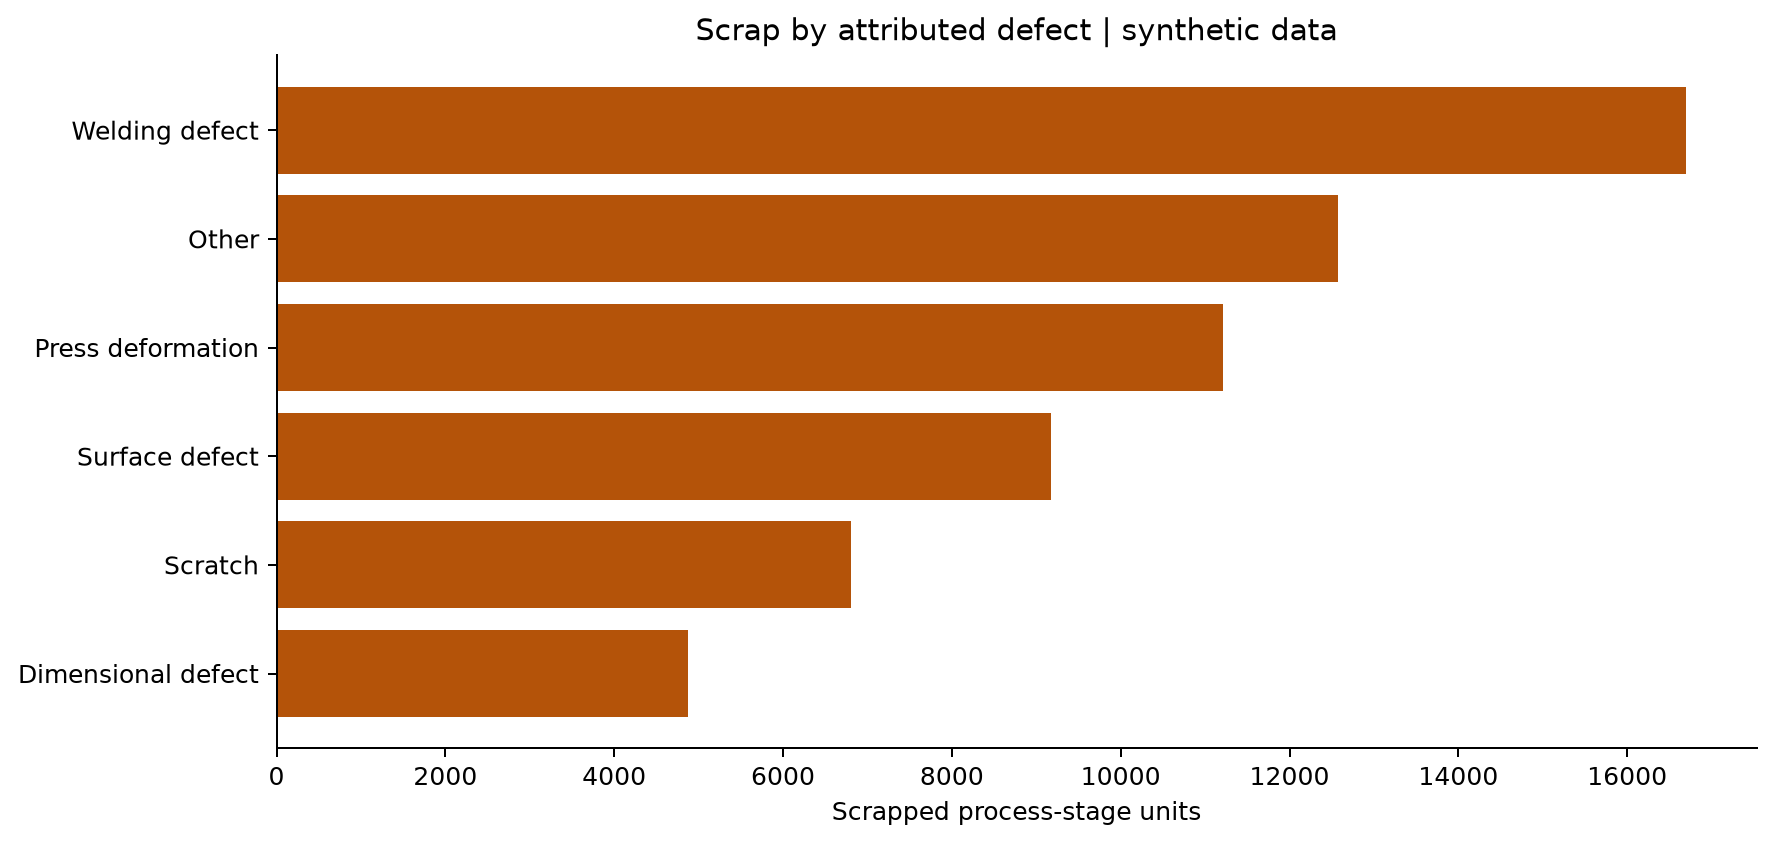

In [2]:
defects = pareto(clean[clean.scrap_quantity>0], 'defect_type', 'scrap_quantity')
display(defects)
for dimension in ['machine_id','shift','product_type']:
    display(grouped(clean,dimension)[[dimension,'scrap_quantity','scrap_rate','quality']])
display(Image(filename=str(ROOT / 'reports/figures/scrap_by_defect.png')))

## Interpretation

Defect attribution is simplified to one label per observation. Inspection discoveries are not proof that inspection caused the defect.

See docs/methodology.md for definitions and limitations.